### Import necessary libraries

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg
import warnings
from colorama import Fore
from sklearn.mixture import BayesianGaussianMixture
from sklearn.model_selection import KFold
from scipy.stats import norm
from sklearn.exceptions import ConvergenceWarning

# Read in data

### Decide if splitting sets or not

In [97]:
split = False # rest in between sets negates fatigue, if present

if split:
    raw_df = pd.read_csv("/home/abbie/projects/TECH646-Haptic-Results/data/raw_data_split.csv")
    raw_df.set_index('subject_trial', inplace=True)
else:
    raw_df = pd.read_csv("/home/abbie/projects/TECH646-Haptic-Results/data/raw_data.csv")
    raw_df.set_index('subject', inplace=True)

### Decide for all or only small

In [98]:
small_only = False # switching up between big and small created inconsistency

if small_only:
    raw_df = raw_df.drop(raw_df.filter(like='big', axis=1), axis=1)

print(raw_df.shape[1])

40


### Plot all the raw data

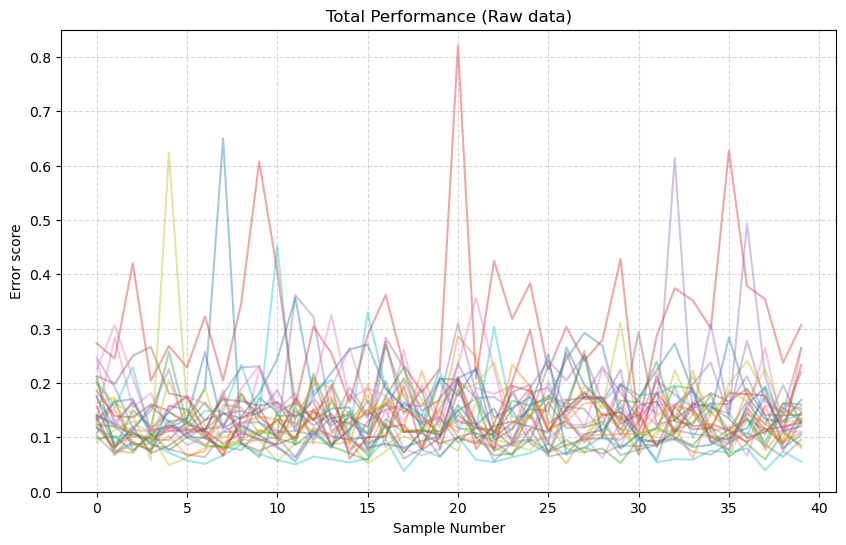

In [99]:
plt.figure(figsize=(10, 6))
for i, row in raw_df.iterrows():
    plt.plot(range(0, raw_df.shape[1]), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Raw data)")
plt.xlabel("Sample Number")
plt.ylabel("Error score")
plt.ylim(0, 0.85)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Clean up the data by removing outliers

In [100]:
# can allow for more outliers for low performance - less difficult to determine
std_dev = 3 # how many standard deviations from the mean data can be

# calculate z scores
z_scores = (raw_df - raw_df.mean()) / raw_df.std()

# replace values with NaN if they’re more than determined standard deviations from the mean
df_clean = raw_df.mask(np.abs(z_scores) > std_dev)

# fill NaN with the median of that column instead of dropping
df_clean = df_clean.apply(lambda x: x.fillna(x.median()), axis=0)

#### Visualize cleaned up data

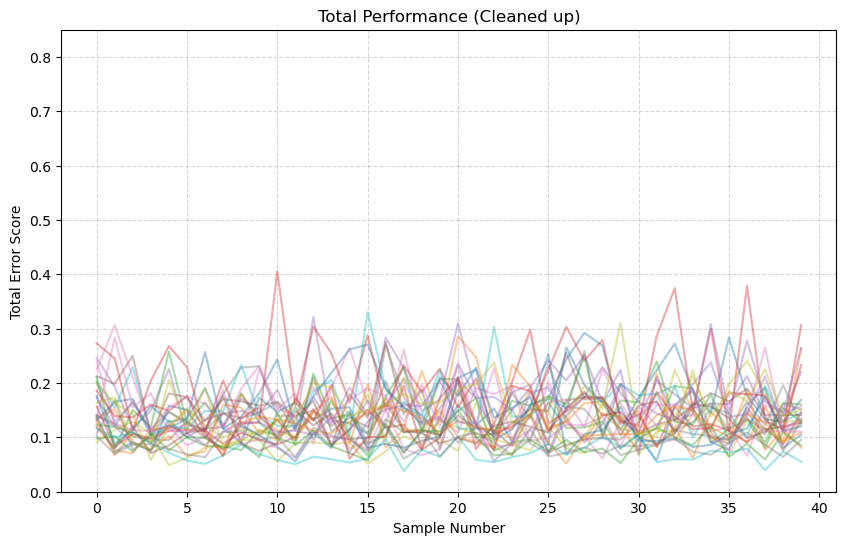

In [101]:
plt.figure(figsize=(10, 6))
for i, row in df_clean.iterrows():
    plt.plot(range(0, raw_df.shape[1]), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Cleaned up)")
plt.xlabel("Sample Number")
plt.ylabel("Total Error Score")
plt.ylim(0, 0.85)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Determine percentage change at various window sizes

## Make function to calculate the change

In [102]:
def get_change(start, end):
    difference = end - start
    change = difference / start
    percent_change = change * 100
    return percent_change

## Calculate each percentage change

In [103]:
if not small_only:
    window_sizes = [5, 9, 17, 21]
else:
    window_sizes = [3, 6, 9, 15] # good balance of short and long term

percent_dict = {}

for window in window_sizes:
    all_percents = []
    for i, row in df_clean.iterrows():
        errors = row.values
        for start in range(len(errors) - window + 1):
            start_val = errors[start]

            end_val = errors[start + window - 1]

            all_percents.append(get_change(start_val, end_val))

    percent_dict[window] = np.array(all_percents)

### Plot each percentage change

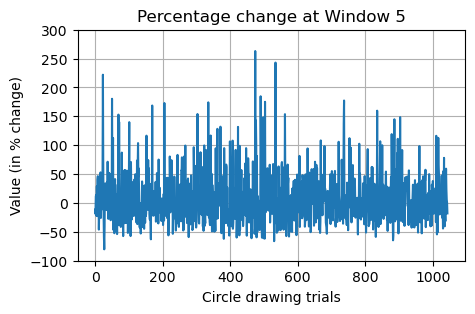

Number of percent samples: 1044


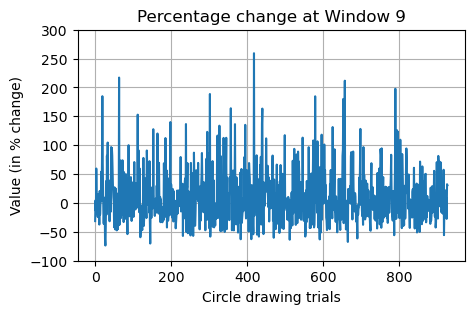

Number of percent samples: 928


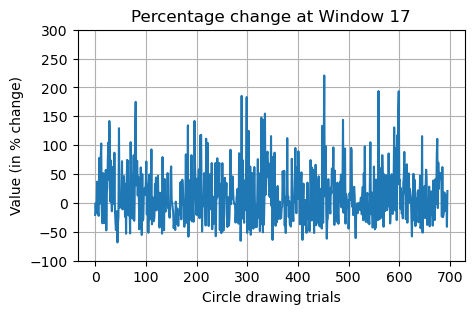

Number of percent samples: 696


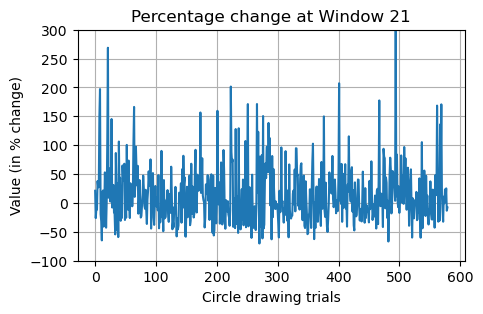

Number of percent samples: 580


In [104]:
for window, percent in percent_dict.items():
    plt.figure(figsize=(5, 3))
    plt.plot(range(len(percent)), percent)
    plt.title(f'Percentage change at Window {window}')
    plt.xlabel('Circle drawing trials')
    plt.ylabel('Value (in % change)')
    plt.ylim(-100, 300)
    plt.grid(True)
    plt.show()
    print("Number of percent samples:", len(percent))

### Clean up and remove outliers

In [105]:
# can allow for more outliers for low performance - less difficult to determine
std_dev = 3  # how many standard deviations from the mean data can be

# replace outliers with median for each window
percent_dict_cleaned = {}

for window, percents in percent_dict.items():
    # calculate z-scores
    mean = np.nanmean(percents)
    std = np.nanstd(percents)
    z_scores = (percents - mean) / std
    
    # replace values with NaN if they're more than std_dev standard deviations from mean
    percents_masked = np.where(np.abs(z_scores) > std_dev, np.nan, percents)
    
    # fill NaN with the median
    median = np.nanmedian(percents_masked)
    percents_cleaned = np.where(np.isnan(percents_masked), median, percents_masked)
    
    percent_dict_cleaned[window] = percents_cleaned
    
    # print replacement statistics
    n_replaced = np.sum(np.abs(z_scores) > std_dev)
    pct_replaced = 100 * n_replaced / len(percents)
    print(f"Window {window}: Replaced {n_replaced} outliers ({pct_replaced:.1f}%) with median {median:.4f}")

# use cleaned data for downstream analysis
percent_dict = percent_dict_cleaned

Window 5: Replaced 18 outliers (1.7%) with median -0.3316
Window 9: Replaced 11 outliers (1.2%) with median 1.6624
Window 17: Replaced 8 outliers (1.1%) with median 4.5800
Window 21: Replaced 11 outliers (1.9%) with median 3.1348


#### Plot cleaned up percentage changes

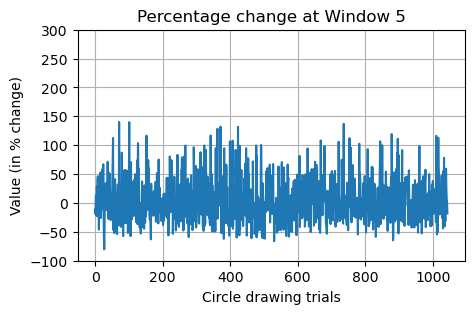

Number of percent samples: 1044


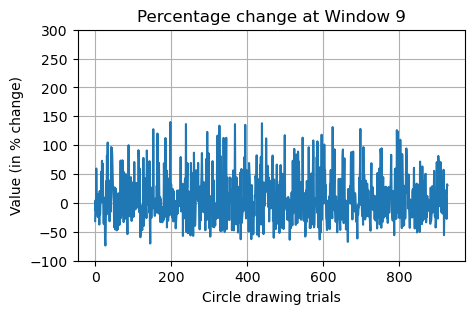

Number of percent samples: 928


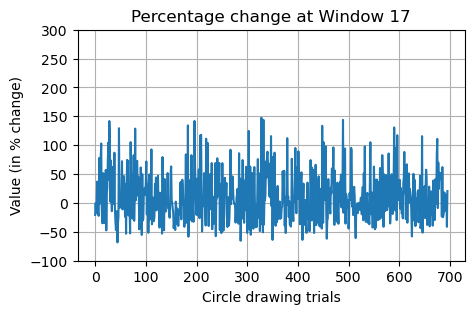

Number of percent samples: 696


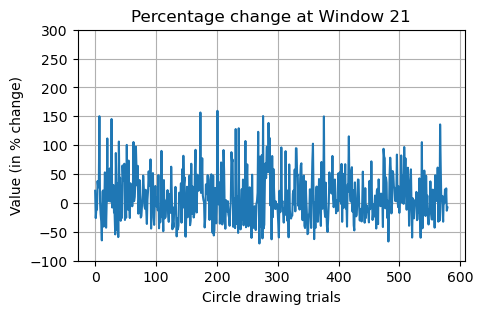

Number of percent samples: 580


In [106]:
for window, percent in percent_dict.items():
    plt.figure(figsize=(5, 3))
    plt.plot(range(len(percent)), percent)
    plt.title(f'Percentage change at Window {window}')
    plt.xlabel('Circle drawing trials')
    plt.ylabel('Value (in % change)')
    plt.ylim(-100, 300)
    plt.grid(True)
    plt.show()
    print("Number of percent samples:", len(percent))

# Use Gaussian Mixture Model to label

## Find thresholds for given probability

In [107]:
high_probability = 0.9
low_probability = 0.98
high_conf_percent = str(high_probability * 100) + "%"
low_conf_percent = str(low_probability * 100) + "%"

## Validation with cross-validation

### Helper functions for cross-validation

In [108]:
def fit_gmm_and_get_thresholds(percent_array, high_desired_probability, low_desired_probability,
                                n_components=3, n_init=1000, tol=0.001,
                                random_state=None):
    """Same fitting logic as the main threshold cell above, but reusable
    so it can be re-run on different subsets of subjects."""
    percents_reshaped = percent_array.reshape(-1, 1)
    gmm = BayesianGaussianMixture(n_components=n_components, n_init=n_init,
                                   tol=tol, random_state=random_state)
    gmm.fit(percents_reshaped)

    means = gmm.means_.flatten()
    sigmas = np.sqrt(gmm.covariances_.flatten())
    order = np.argsort(means)
    means, sigmas, weights = means[order], sigmas[order], gmm.weights_[order]

    x = np.linspace(np.min(percent_array), np.max(percent_array), 10000)
    pdfs = np.array([w * norm.pdf(x, m, s) for w, m, s in zip(weights, means, sigmas)])
    posteriors = pdfs / np.sum(pdfs, axis=0)

    high_thr = x[np.where(posteriors[0] >= high_desired_probability)[0][-1]] \
        if np.any(posteriors[0] >= high_desired_probability) else np.nan
    low_thr = x[np.where(posteriors[2] >= low_desired_probability)[0][0]] \
        if np.any(posteriors[2] >= low_desired_probability) else np.nan

    return high_thr, low_thr, means, sigmas, weights


def compute_percents_for_subjects(df, window):
    """Pool percent-change values across all subjects/windows in df, same
    logic as the original percent_dict computation."""
    percents = []
    for _, row in df.iterrows():
        errors = row.values
        for start in range(len(errors) - window + 1):
            percents.append(get_change(errors[start], errors[start + window - 1]))
    return np.array(percents)


def clean_percents(percents, std_dev=std_dev):
    """Same outlier handling as the original percent_dict_cleaned step."""
    mean_, std_ = np.nanmean(percents), np.nanstd(percents)
    z = (percents - mean_) / std_
    masked = np.where(np.abs(z) > std_dev, np.nan, percents)
    median_ = np.nanmedian(masked)
    return np.where(np.isnan(masked), median_, masked)


### Run cross-validation across 10 splits to check threshold stability

In [109]:
subjects = df_clean.index.to_numpy()
n_splits = 10
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
n_inits = 1000
cv_thresholds = {}
gmm_results = {}

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    for window in window_sizes:
        fold_high, fold_low = [], []
        for fold_i, (train_idx, test_idx) in enumerate(kf.split(subjects)):
            train_df = df_clean.loc[subjects[train_idx]]
            train_percents = compute_percents_for_subjects(train_df, window)
            train_percents = clean_percents(train_percents)
            high_thr, low_thr, *_ = fit_gmm_and_get_thresholds(
                train_percents, high_probability, low_probability,
                n_init=n_inits,
                random_state=fold_i
            )
            fold_high.append(high_thr)
            fold_low.append(low_thr)

        cv_thresholds[window] = {
            "high": fold_high,
            "low": fold_low,
            "mean_high": np.nanmean(fold_high),
            "mean_low": np.nanmean(fold_low),
            "std_high": np.nanstd(fold_high),
            "std_low": np.nanstd(fold_low),
            "min_high": np.nanmin(fold_high),
            "max_high": np.nanmax(fold_high),
            "min_low": np.nanmin(fold_low),
            "max_low": np.nanmax(fold_low),
            "n_valid_high": int(np.sum(~np.isnan(fold_high))),
            "n_valid_low": int(np.sum(~np.isnan(fold_low))),
        }

        full_percents = compute_percents_for_subjects(df_clean, window)
        full_percents = clean_percents(full_percents)
        _, _, means, sigmas, weights = fit_gmm_and_get_thresholds(
            full_percents, high_probability, low_probability,
            n_init=n_inits,
            random_state=42
        )
        gmm_results[window] = {"means": means, "sigmas": sigmas, "weights": weights}

        print(f"Window {window}:")
        print(f"  CV high threshold at {high_conf_percent}: {cv_thresholds[window]['mean_high']:.3f} +/- {cv_thresholds[window]['std_high']:.3f} "
              f"(range {cv_thresholds[window]['min_high']:.3f} to {cv_thresholds[window]['max_high']:.3f})")
        print(f"    Threshold found at {cv_thresholds[window]['n_valid_high']}/{n_splits} folds.")
        print(f"  CV low threshold at {low_conf_percent}: {cv_thresholds[window]['mean_low']:.3f} +/- {cv_thresholds[window]['std_low']:.3f} "
              f"(range {cv_thresholds[window]['min_low']:.3f} to {cv_thresholds[window]['max_low']:.3f})")
        print(f"    Threshold found at {cv_thresholds[window]['n_valid_low']}/{n_splits} folds.")
        print()

Window 5:
  CV high threshold at 90.0%: -42.433 +/- 5.880 (range -50.404 to -32.806)
    Threshold found at 10/10 folds.
  CV low threshold at 98.0%: 111.167 +/- 3.021 (range 107.513 to 116.074)
    Threshold found at 10/10 folds.

Window 9:
  CV high threshold at 90.0%: -43.159 +/- 6.300 (range -54.541 to -30.360)
    Threshold found at 10/10 folds.
  CV low threshold at 98.0%: 85.753 +/- 4.315 (range 79.452 to 92.194)
    Threshold found at 10/10 folds.

Window 17:
  CV high threshold at 90.0%: -48.326 +/- 3.946 (range -56.811 to -44.419)
    Threshold found at 8/10 folds.
  CV low threshold at 98.0%: 114.771 +/- 7.791 (range 96.840 to 123.840)
    Threshold found at 10/10 folds.

Window 21:
  CV high threshold at 90.0%: -27.172 +/- 4.726 (range -36.854 to -20.408)
    Threshold found at 9/10 folds.
  CV low threshold at 98.0%: 152.608 +/- 7.265 (range 141.891 to 165.268)
    Threshold found at 7/10 folds.



### Plot low performance threshold stability across folds

/tmp/ipykernel_1228/4252188801.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(low_data, labels=window_sizes)
/tmp/ipykernel_1228/4252188801.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


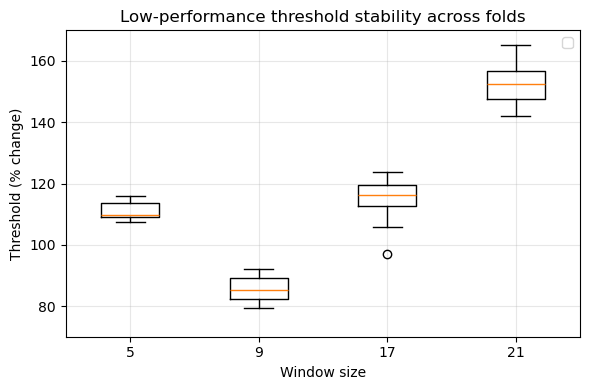

In [123]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

low_data = [
    [v for v in cv_thresholds[w]["low"] if not np.isnan(v)]
    for w in window_sizes
]

ax.boxplot(low_data, labels=window_sizes)
ax.set_title("Low-performance threshold stability across folds")
ax.set_xlabel("Window size")
ax.set_ylabel("Threshold (% change)")
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(70,170)

plt.tight_layout()
plt.show()

### Plot high performance threshold stability across folds

/tmp/ipykernel_1228/1029654296.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(high_data, labels=window_sizes)


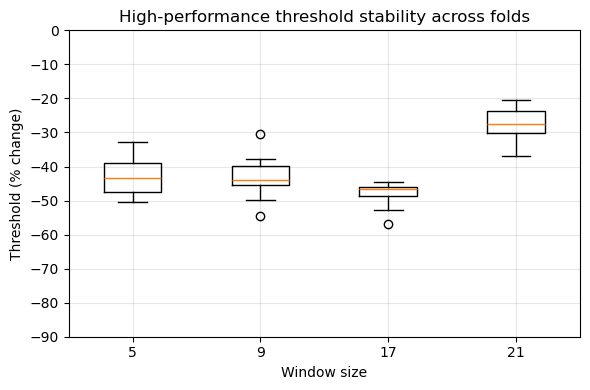

In [124]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

high_data = [
    [v for v in cv_thresholds[w]["high"] if not np.isnan(v)]
    for w in window_sizes
]

ax.boxplot(high_data, labels=window_sizes)
ax.set_title("High-performance threshold stability across folds")
ax.set_xlabel("Window size")
ax.set_ylabel("Threshold (% change)")
ax.grid(alpha=0.3)
ax.set_ylim(-90, 0)

plt.tight_layout()
plt.show()

### Check classification agreement for low performance

In [125]:
low_agreement_results = {}
print("Low performance:")

for window in window_sizes:
    fold_thresholds = cv_thresholds[window]["low"]
    definitive_low_thr = cv_thresholds[window]["mean_low"]
    fold_agreements = []

    if np.isnan(definitive_low_thr):
        print(f"Window {window}: skipped (no valid definitive threshold)")
        low_agreement_results[window] = fold_agreements
        continue

    for fold_i, (train_idx, test_idx) in enumerate(kf.split(subjects)):
        fold_thr = fold_thresholds[fold_i]
        if np.isnan(fold_thr):
            continue  # skip folds with no valid threshold

        test_df = df_clean.loc[subjects[test_idx]]

        agree, total = 0, 0
        for _, row in test_df.iterrows():
            errors = row.values
            for start in range(len(errors) - window + 1):
                pct = get_change(errors[start], errors[start + window - 1])
                if np.isnan(pct):
                    continue

                label_definitive = pct < definitive_low_thr
                label_fold = pct < fold_thr
                agree += int(label_definitive == label_fold)
                total += 1

        if total > 0:
            fold_agreements.append(agree / total)

    low_agreement_results[window] = fold_agreements

    if fold_agreements:
        print(f"Window {window}: mean classification agreement across folds = "
              f"{np.mean(fold_agreements) * 100:.1f}% "
              f"(min {np.min(fold_agreements)*100:.1f}%, max {np.max(fold_agreements)*100:.1f}%)")
    else:
        print(f"Window {window}: no valid folds to compute agreement")

Low performance:
Window 5: mean classification agreement across folds = 99.7% (min 98.1%, max 100.0%)
Window 9: mean classification agreement across folds = 98.8% (min 96.9%, max 100.0%)
Window 17: mean classification agreement across folds = 99.2% (min 97.2%, max 100.0%)
Window 21: mean classification agreement across folds = 100.0% (min 100.0%, max 100.0%)


### Check classification agreement for high performance

In [138]:
high_agreement_results = {}
print("High performance:")

for window in window_sizes:
    fold_thresholds = cv_thresholds[window]["high"]
    definitive_high_thr = cv_thresholds[window]["mean_high"]
    fold_agreements = []

    if np.isnan(definitive_high_thr):
        print(f"Window {window}: skipped (no valid definitive threshold)")
        high_agreement_results[window] = fold_agreements
        continue

    for fold_i, (train_idx, test_idx) in enumerate(kf.split(subjects)):
        fold_thr = fold_thresholds[fold_i]
        if np.isnan(fold_thr):
            continue  # skip folds with no valid threshold

        test_df = df_clean.loc[subjects[test_idx]]

        agree, total = 0, 0
        for _, row in test_df.iterrows():
            errors = row.values
            for start in range(len(errors) - window + 1):
                pct = get_change(errors[start], errors[start + window - 1])
                if np.isnan(pct):
                    continue

                label_definitive = pct < definitive_high_thr
                label_fold = pct < fold_thr
                agree += int(label_definitive == label_fold)
                total += 1

        if total > 0:
            fold_agreements.append(agree / total)

    high_agreement_results[window] = fold_agreements

    if fold_agreements:
        print(f"Window {window}: mean classification agreement across folds = "
              f"{np.mean(fold_agreements) * 100:.1f}% "
              f"(min {np.min(fold_agreements)*100:.1f}%, max {np.max(fold_agreements)*100:.1f}%)")
    else:
        print(f"Window {window}: no valid folds to compute agreement")

High performance:
Window 5: mean classification agreement across folds = 97.5% (min 93.5%, max 100.0%)
Window 9: mean classification agreement across folds = 97.2% (min 91.7%, max 100.0%)
Window 17: mean classification agreement across folds = 98.8% (min 95.8%, max 100.0%)
Window 21: mean classification agreement across folds = 97.7% (min 93.3%, max 100.0%)


### Interclass correlation

#### Low performance

In [114]:
low_icc_results = {}

for window in window_sizes:
    definitive_thr = np.nanmean(cv_thresholds[window]["low"])

    if np.isnan(definitive_thr):
        print(f"Window {window}: skipped (no valid definitive threshold)")
        print()
        continue

    rows = []
    target_id = 0

    for fold_i, (train_idx, test_idx) in enumerate(kf.split(subjects)):
        fold_thr = cv_thresholds[window]["low"][fold_i]
        if np.isnan(fold_thr):
            continue  # skip folds with no valid threshold

        test_df = df_clean.loc[subjects[test_idx]]

        for _, row in test_df.iterrows():
            errors = row.values
            for start in range(len(errors) - window + 1):
                pct = get_change(errors[start], errors[start + window - 1])
                if np.isnan(pct):
                    continue  # skip undefined percent-change values

                margin_definitive = pct - definitive_thr
                margin_fold = pct - fold_thr

                rows.append({"target": target_id, "rater": "definitive", "score": margin_definitive})
                rows.append({"target": target_id, "rater": "fold", "score": margin_fold})
                target_id += 1

    if not rows:
        print(f"Window {window}: no valid data to compute ICC")
        print()
        continue

    long_df = pd.DataFrame(rows)
    icc = pg.intraclass_corr(data=long_df, targets="target", raters="rater", ratings="score")
    low_icc_results[window] = icc
    print(f"Window {window}:")
    print(icc)
    print()

Window 5:
       Type       ICC           F   df1   df2  pval        CI95
0  ICC(1,1)  0.997597  831.305405  1043  1044   0.0  [1.0, 1.0]
1  ICC(A,1)  0.997597  830.509136  1043  1043   0.0  [1.0, 1.0]
2  ICC(C,1)  0.997595  830.509136  1043  1043   0.0  [1.0, 1.0]
3  ICC(1,k)  0.998797  831.305405  1043  1044   0.0  [1.0, 1.0]
4  ICC(A,k)  0.998797  830.509136  1043  1043   0.0  [1.0, 1.0]
5  ICC(C,k)  0.998796  830.509136  1043  1043   0.0  [1.0, 1.0]

Window 9:
       Type       ICC           F  df1  df2  pval         CI95
0  ICC(1,1)  0.995346  428.714369  927  928   0.0  [0.99, 1.0]
1  ICC(A,1)  0.995346  428.466102  927  927   0.0  [0.99, 1.0]
2  ICC(C,1)  0.995343  428.466102  927  927   0.0  [0.99, 1.0]
3  ICC(1,k)  0.997667  428.714369  927  928   0.0   [1.0, 1.0]
4  ICC(A,k)  0.997667  428.466102  927  927   0.0   [1.0, 1.0]
5  ICC(C,k)  0.997666  428.466102  927  927   0.0   [1.0, 1.0]

Window 17:
       Type       ICC           F  df1  df2  pval          CI95
0  ICC(1,1)  0

#### High performance

In [115]:
high_icc_results = {}

for window in window_sizes:
    definitive_thr = np.nanmean(cv_thresholds[window]["high"])

    if np.isnan(definitive_thr):
        print(f"Window {window}: skipped (no valid definitive threshold)")
        print()
        continue

    rows = []
    target_id = 0

    for fold_i, (train_idx, test_idx) in enumerate(kf.split(subjects)):
        fold_thr = cv_thresholds[window]["high"][fold_i]
        if np.isnan(fold_thr):
            continue  # skip folds with no valid threshold

        test_df = df_clean.loc[subjects[test_idx]]

        for _, row in test_df.iterrows():
            errors = row.values
            for start in range(len(errors) - window + 1):
                pct = get_change(errors[start], errors[start + window - 1])
                if np.isnan(pct):
                    continue  # skip undefined percent-change values

                margin_definitive = pct - definitive_thr
                margin_fold = pct - fold_thr

                rows.append({"target": target_id, "rater": "definitive", "score": margin_definitive})
                rows.append({"target": target_id, "rater": "fold", "score": margin_fold})
                target_id += 1

    if not rows:
        print(f"Window {window}: no valid data to compute ICC")
        print()
        continue

    long_df = pd.DataFrame(rows)
    icc = pg.intraclass_corr(data=long_df, targets="target", raters="rater", ratings="score")
    high_icc_results[window] = icc
    print(f"Window {window}:")
    print(icc)
    print()

Window 5:
       Type       ICC           F   df1   df2  pval          CI95
0  ICC(1,1)  0.991473  233.537238  1043  1044   0.0  [0.99, 0.99]
1  ICC(A,1)  0.991473  233.839812  1043  1043   0.0  [0.99, 0.99]
2  ICC(C,1)  0.991484  233.839812  1043  1043   0.0  [0.99, 0.99]
3  ICC(1,k)  0.995718  233.537238  1043  1044   0.0    [1.0, 1.0]
4  ICC(A,k)  0.995718  233.839812  1043  1043   0.0    [1.0, 1.0]
5  ICC(C,k)  0.995724  233.839812  1043  1043   0.0    [1.0, 1.0]

Window 9:
       Type       ICC          F  df1  df2  pval          CI95
0  ICC(1,1)  0.990013  199.26798  927  928   0.0  [0.99, 0.99]
1  ICC(A,1)  0.990013  199.05366  927  927   0.0  [0.99, 0.99]
2  ICC(C,1)  0.990003  199.05366  927  927   0.0  [0.99, 0.99]
3  ICC(1,k)  0.994982  199.26798  927  928   0.0   [0.99, 1.0]
4  ICC(A,k)  0.994982  199.05366  927  927   0.0   [0.99, 1.0]
5  ICC(C,k)  0.994976  199.05366  927  927   0.0   [0.99, 1.0]

Window 17:
       Type       ICC           F  df1  df2  pval        CI95
0 

### Summarize validation

In [137]:
header = (f"{'Window':<8}{'CV low thr (std)':<22}{'Threshold found in folds':<30}{'Low Agreement %':<20}"
          f"{'CV high thr (std)':<22}{'Threshold found in folds':<30}{'High Agreement %':<20}")
print(header)

for window in window_sizes:
    cv_mean_low = cv_thresholds[window]["mean_low"]
    cv_std_low = cv_thresholds[window]["std_low"]
    cv_mean_high = cv_thresholds[window]["mean_high"]
    cv_std_high = cv_thresholds[window]["std_high"]
    valid_low = f"{cv_thresholds[window]['n_valid_low']}/{n_splits}"
    valid_high = f"{cv_thresholds[window]['n_valid_high']}/{n_splits}"

    low_agree_list = low_agreement_results.get(window, [])
    high_agree_list = high_agreement_results.get(window, [])

    low_agree_pct = np.mean(low_agree_list) * 100 if low_agree_list else np.nan
    high_agree_pct = np.mean(high_agree_list) * 100 if high_agree_list else np.nan

    inner_low = f"{cv_mean_low:.3f} ({cv_std_low:.3f})"
    inner_high = f"{cv_mean_high:.3f} ({cv_std_high:.3f})"

    print(f"{window:<8}{inner_low:<22}{valid_low:<30}{low_agree_pct:<20.1f}"
          f"{inner_high:<22}{valid_high:<30}{high_agree_pct:<20.1f}")

Window  CV low thr (std)      Threshold found in folds      Low Agreement %     CV high thr (std)     Threshold found in folds      High Agreement %    
5       111.167 (3.021)       10/10                         99.7                -42.433 (5.880)       10/10                         97.5                
9       85.753 (4.315)        10/10                         98.8                -43.159 (6.300)       10/10                         97.2                
17      114.771 (7.791)       10/10                         99.2                -48.326 (3.946)       8/10                          98.8                
21      152.608 (7.265)       7/10                          100.0               -27.172 (4.726)       9/10                          97.7                


## Display GMM findings

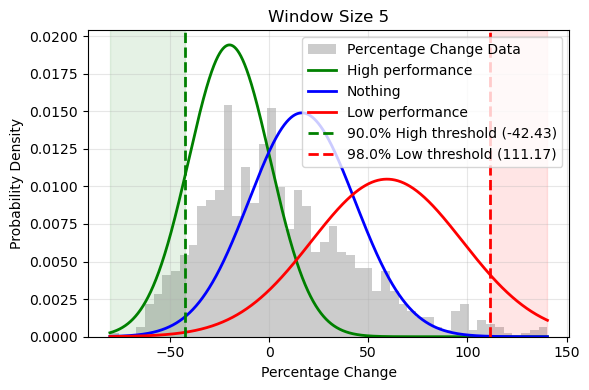

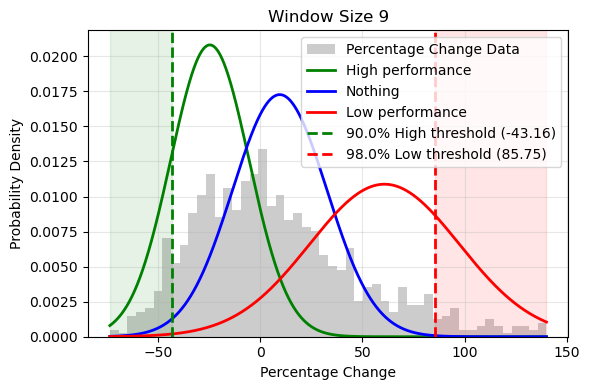

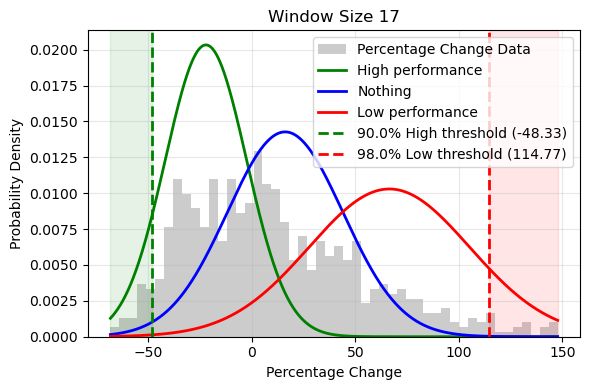

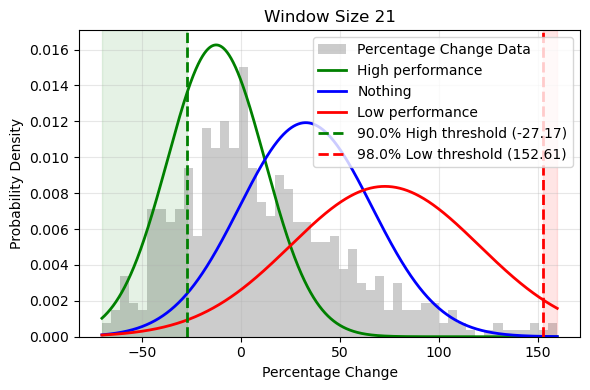

In [128]:
for window in window_sizes: 
    results = gmm_results[window]
    means = results["means"]
    sigmas = results["sigmas"]
    percents = percent_dict[window]

    # compute Gaussian PDFs
    x = np.linspace(np.nanmin(percents), np.nanmax(percents), 10000)
    pdfs = [norm.pdf(x, mu, sigma) for mu, sigma in zip(means, sigmas)]
    
    # extract confidence thresholds
    t_high = cv_thresholds[window]["mean_high"]
    t_low = cv_thresholds[window]["mean_low"]

    # plot histogram
    plt.figure(figsize=(6, 4))
    plt.hist(percents, bins=50, density=True, alpha=0.4, color='gray', label='Percentage Change Data')

    # plot Gaussians
    colors = ['green', 'blue', 'red']
    labels = ['High performance', 'Nothing', 'Low performance']
    for pdf, color, label in zip(pdfs, colors, labels):
        plt.plot(x, pdf, color=color, lw=2, label=label)

    # shaded regions for high-confidence areas
    if not np.isnan(t_high):
        plt.axvspan(x.min(), t_high, color='green', alpha=0.1)
    if not np.isnan(t_low):
        plt.axvspan(t_low, x.max(), color='red', alpha=0.1)

    # plot Sconfidence thresholds
    if not np.isnan(t_high):
        plt.axvline(t_high, color='green', linestyle='--', lw=2, label=f'{high_conf_percent} High threshold ({t_high:.2f})')
    if not np.isnan(t_low):
        plt.axvline(t_low, color='red', linestyle='--', lw=2, label=f'{low_conf_percent} Low threshold ({t_low:.2f})')

    
    plt.title(f"Window Size {window}")
    plt.xlabel("Percentage Change")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Visualize thresholds in trials

### Prepare for visualization

In [129]:
for window in window_sizes:
    print("Window size:", window)
    low_threshold = cv_thresholds[window]["mean_low"]
    print(f"Low performance threshold: {low_threshold}")
    high_threshold = cv_thresholds[window]["mean_high"]
    print(f"High performance threshold: {high_threshold}")

    modes_list = []

    for i, row in df_clean.iterrows():
        subject_modes = []
        errors = row.values
        for start in range(len(errors) - window + 1):
            window_vals = errors[start:start+window]
            x = np.arange(window)
            
            start_val = errors[start]

            end_val = errors[start + window - 1]

            percent_changed = get_change(start_val, end_val)

            if percent_changed > low_threshold:
                subject_modes.append("low performance")
            elif percent_changed < high_threshold:
                subject_modes.append("high performance")
            else:
                subject_modes.append("nothing")
        
        # pad the beginning so the mode array is same length as trials - no reading at the beginning
        subject_modes = ["nothing"]*(window-1) + subject_modes
        modes_list.append(subject_modes)

    # convert to DataFrame for easy handling
    modes_df = pd.DataFrame(modes_list, index=df_clean.index, columns=df_clean.columns)

    overall_counts = modes_df.stack().value_counts()
    low_count = overall_counts.get("low performance", 0)
    print(f"Low performance count: {low_count}")
    high_count = overall_counts.get("high performance", 0)
    print(f"High performance count: {high_count}")

Window size: 5
Low performance threshold: 111.16720180722533
High performance threshold: -42.43268926472944
Low performance count: 31
High performance count: 75
Window size: 9
Low performance threshold: 85.75331468968545
High performance threshold: -43.159232817376065
Low performance count: 57
High performance count: 70
Window size: 17
Low performance threshold: 114.7714234662139
High performance threshold: -48.326057733676365
Low performance count: 25
High performance count: 25
Window size: 21
Low performance threshold: 152.60827524710345
High performance threshold: -27.171572128025723
Low performance count: 13
High performance count: 103


### Visualize at given window

In [130]:
window = 9 # size of window to visualize - user determined

In [131]:
print("Window size:", window)
low_threshold = cv_thresholds[window]["mean_low"]
print(f"Low performance threshold: {low_threshold}")
high_threshold = cv_thresholds[window]["mean_high"]
print(f"High performance threshold: {high_threshold}")

modes_list = []

for i, row in df_clean.iterrows():
    subject_modes = []
    errors = row.values
    for start in range(len(errors) - window + 1):
        window_vals = errors[start:start+window]
        x = np.arange(window)
        
        start_val = errors[start]

        end_val = errors[start + window - 1]

        percent_changed = get_change(start_val, end_val)

        if percent_changed > low_threshold:
            subject_modes.append("low performance")
        elif percent_changed < high_threshold:
            subject_modes.append("high performance")
        else:
            subject_modes.append("nothing")
    
    # pad the beginning so the mode array is same length as trials - no reading at the beginning
    subject_modes = ["nothing"]*(window-1) + subject_modes
    modes_list.append(subject_modes)

# convert to DataFrame for easy handling
modes_df = pd.DataFrame(modes_list, index=df_clean.index, columns=df_clean.columns)

Window size: 9
Low performance threshold: 85.75331468968545
High performance threshold: -43.159232817376065


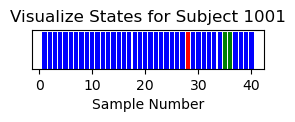

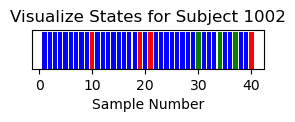

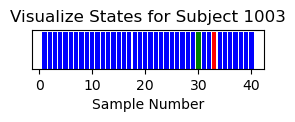

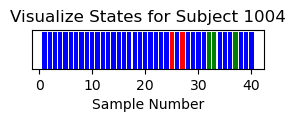

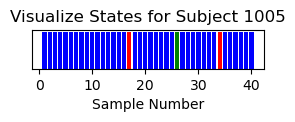

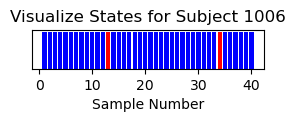

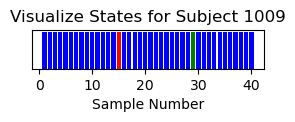

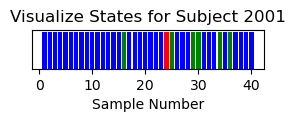

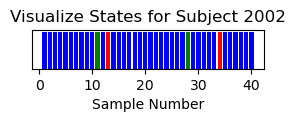

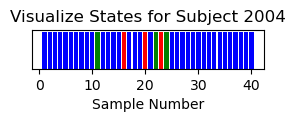

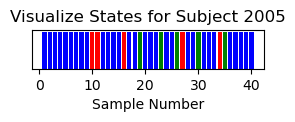

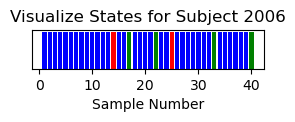

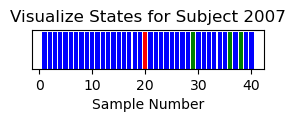

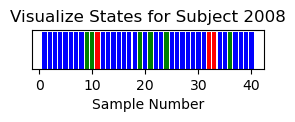

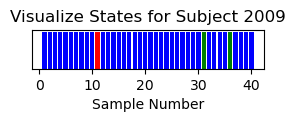

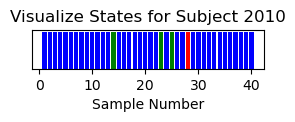

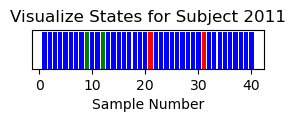

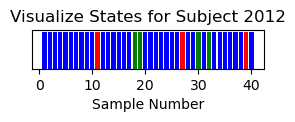

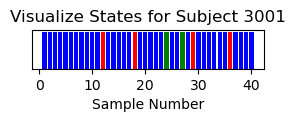

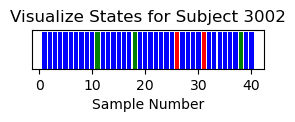

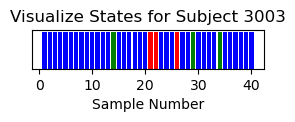

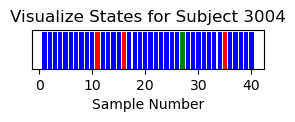

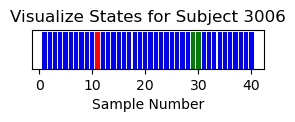

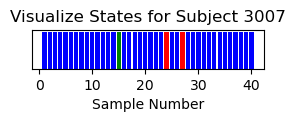

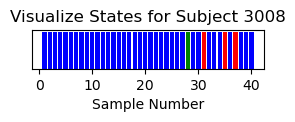

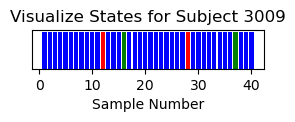

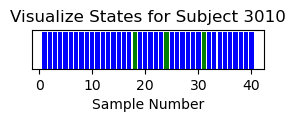

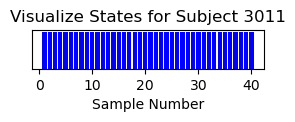

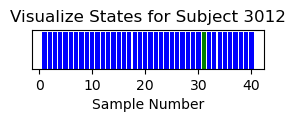

In [132]:
for i in range(0,raw_df.shape[0]):
    subject = i
    colors = {"nothing": "blue", "low performance": "red", "high performance": "green"}
    modes = modes_df.iloc[subject]

    plt.figure(figsize=(3,0.5))
    for i, mode in enumerate(modes):
        plt.bar(i+1, 1, color=colors[mode])

    plt.title(f"Visualize States for Subject {df_clean.index[subject]}")
    plt.xlabel("Sample Number")
    plt.yticks([])
    plt.show()